# CDC

https://wonder.cdc.gov/

There are 6 tables in database
- **mcd99_cod:** provides data on a cod basis (1999 - 2020 data)
- **mcd18_cod:** provides data on a cod basis (2018+)
- **mcd18_monthly:** provides monthly data (2018+)
- **mi:** provides data from on a more aggregate level (1979-2020)
- **mcd99_check:** provides a check to the cod table as it isn't using grouping (1999 - 2020 data)
- **mcd18_check:** provides a check to the cod table as it isn't using groupings (2018+ data)

sources:
- 1979-1998: https://wonder.cdc.gov/controller/datarequest/D16
- 1999-2020: https://wonder.cdc.gov/controller/datarequest/D76
- 2018+: https://wonder.cdc.gov/controller/datarequest/D176

code support:
- https://github.com/alipphardt/cdc-wonder-api


## Import

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
from sklearn.linear_model import LinearRegression

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai.experience import charters
from morai.integrations import cdc
from morai.models import core
from morai.utils import helpers, sql

In [3]:
pd.options.display.float_format = "{:,.2f}".format

In [4]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

In [5]:
db_filepath = helpers.FILES_PATH / "integrations" / "cdc" / "cdc.sql"

In [6]:
tables = sql.get_tables(db_filepath=db_filepath)
tables

['mcd99_cod',
 'mcd79_mi',
 'mcd99_mi',
 'mcd79_check',
 'mcd99_check',
 'mcd18_check',
 'mcd18_weekly_influenza',
 'mcd18_monthly_pic',
 'mcd99_monthly_pic',
 'mcd99_monthly_cod',
 'mcd18_monthly',
 'mcd18_weekly',
 'mcd18_weekly_pic',
 'mcd18_monthly_cod',
 'mcd18_cod',
 'mcd18_mi']

## COD

### SQL
Load from SQL database

In [7]:
mcd99_cod = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_cod")

In [8]:
mcd18_cod = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_cod")

### Aggregate
Aggregating the historical and provisional and mapping columns to more friendly names

In [9]:
# variable to map
CATEGORY_COL = "simple_grouping"

In [10]:
# filter and concat
mcd18_cod = mcd18_cod[mcd18_cod["year"] >= 2021]
cod_all = pd.concat([mcd99_cod, mcd18_cod], ignore_index=True)

In [11]:
# map the variable from reference
cod_all = cdc.map_reference(
    df=cod_all, col=CATEGORY_COL, on_dict={"icd_sub_chapter": "wonder_sub_chapter"}
)

In [12]:
# normalize partial deaths in recent year
cod_all["deaths"] = cod_all["deaths"].astype(float)
data_through = pd.Timestamp(mcd18_cod["data_through"].max())
start_of_year = pd.Timestamp(f"{data_through.year}-01-01")
days_elapsed = (data_through - start_of_year).days + 1
factor = 365 / days_elapsed
mask = cod_all["year"] == data_through.year
cod_all.loc[mask, "deaths"] = cod_all.loc[mask, "deaths"] * factor

### Chart

In [13]:
# sorting by deaths
category_orders = charters.get_category_orders(
    df=cod_all, category=CATEGORY_COL, measure="deaths"
)

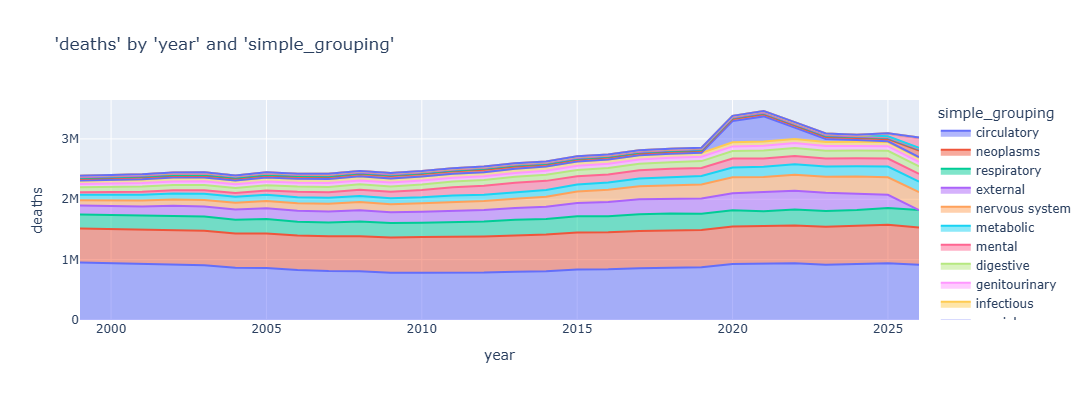

In [14]:
charters.chart(
    df=cod_all,
    x_axis="year",
    y_axis="deaths",
    color=CATEGORY_COL,
    type="area",
    category_orders=category_orders,
)

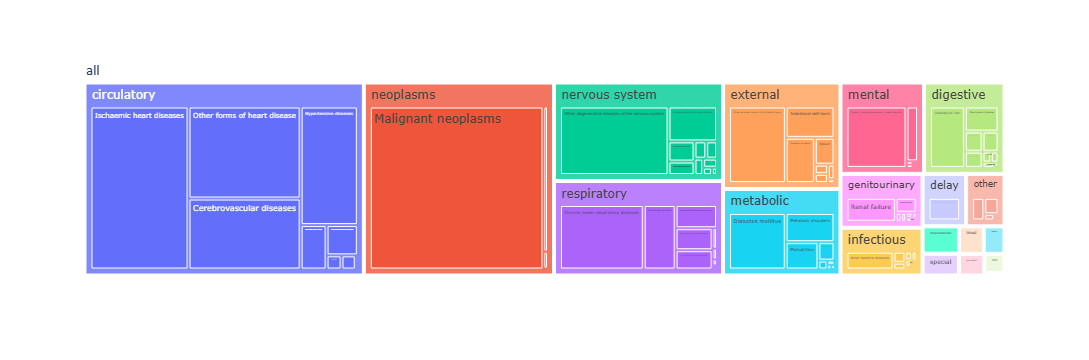

In [15]:
fig = px.treemap(
    cod_all[(cod_all[CATEGORY_COL] != "total") & (cod_all["year"] == 2025)],
    path=[px.Constant("all"), CATEGORY_COL, "icd_sub_chapter"],
    values="deaths",
)
fig

In [16]:
deaths_pivot, names_pivot = cdc.get_top_deaths_by_age_group(df=cod_all, year=2018)

### Trends

In [17]:
age_group_value = []
include_age_groups = age_group_value if age_group_value else cdc.AGE_GROUP_ORDER
cod_all = cod_all[cod_all["age_groups"].isin(include_age_groups)]

In [18]:
# group df by category col and ensure all values are present
cod_all = (
    cod_all.groupby(["year", "age_groups", CATEGORY_COL])
    .agg({"deaths": "sum", "population": "first"})
    .reset_index()
)
idx = pd.MultiIndex.from_product(
    [
        cod_all["year"].unique(),
        cod_all[CATEGORY_COL].unique(),
        cod_all["age_groups"].unique(),
    ],
    names=["year", CATEGORY_COL, "age_groups"],
)
cod_all = (
    cod_all.set_index(["year", CATEGORY_COL, "age_groups"]).reindex(idx).reset_index()
)
cod_all["population"] = cod_all.groupby(["year", "age_groups"])["population"].transform(
    "first"
)

In [19]:
# create totals column
totals = (
    cod_all.groupby(["year", "age_groups"])
    .agg({"deaths": "sum", "population": "first"})
    .reset_index()
)
totals[CATEGORY_COL] = "total"
cod_all = pd.concat([cod_all, totals], ignore_index=True)
cod_all["age_groups"] = pd.Categorical(
    cod_all["age_groups"], categories=cdc.AGE_GROUP_ORDER, ordered=True
)

In [20]:
# calculate crude adj
cod_all = cdc.map_reference(
    df=cod_all,
    col="population_%",
    on_dict={"age_groups": "age_bucket"},
    sheet_name="age_std_2000",
)
total_weight = cod_all.groupby("age_groups")["population_%"].first().sum()
cod_all["population_%"] = cod_all["population_%"] / total_weight
cod_all["crude_adj"] = (
    cod_all["deaths"] / cod_all["population"] * cod_all["population_%"] * 100000
)

#### Predict

In [21]:
# train the data based on year and the category using linear regression
train_df = cod_all[(cod_all["year"] >= 2015) & (cod_all["year"] <= 2019)]
train_df = train_df.groupby(["year", CATEGORY_COL])[["crude_adj"]].sum().reset_index()

In [22]:
# create the models
models = {}
for cod in train_df[CATEGORY_COL].unique():
    cod_subset = train_df[train_df[CATEGORY_COL] == cod]
    X = (cod_subset["year"] - 2015).values.reshape(-1, 1)
    y = cod_subset["crude_adj"].values
    model = LinearRegression().fit(X, y)
    models[cod] = {
        "model": model,
        "coef": model.coef_[0],
        "intercept": model.intercept_,
    }

In [23]:
# make the predictions
test_df = cod_all[(cod_all["year"] >= 2015)]
test_df = (
    test_df.groupby(["year", CATEGORY_COL])[["crude_adj", "deaths", "population"]]
    .sum()
    .reset_index()
)

for cod, model in models.items():
    mask = test_df[CATEGORY_COL] == cod
    X = (test_df.loc[mask, "year"] - 2015).values.reshape(-1, 1)
    test_df.loc[mask, "predictions"] = model["model"].predict(X)

test_df["diff_pct"] = (test_df["crude_adj"] - test_df["predictions"]) / test_df[
    "predictions"
]
test_df["diff_amt"] = (
    (test_df["population"] * test_df["crude_adj"])
    - (test_df["population"] * test_df["predictions"])
) / 100000
test_df["deaths_pred"] = test_df["deaths"] - test_df["diff_amt"]

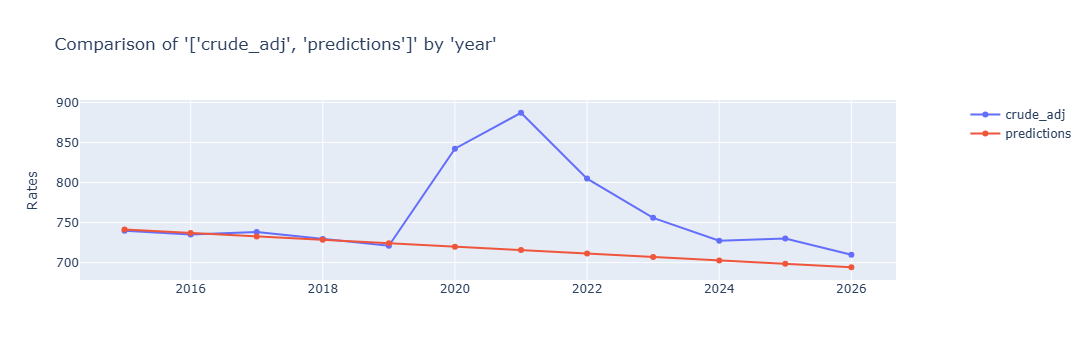

In [24]:
charters.compare_rates(
    df=test_df[test_df[CATEGORY_COL] == "total"],
    x_axis="year",
    rates=["crude_adj", "predictions"],
    display=True,
)

## Monthly

### SQL

In [25]:
mcd18_monthly = cdc.get_cdc_data_sql(
    db_filepath=db_filepath, table_name="mcd18_monthly"
)

In [184]:
mcd18_monthly_cod = cdc.get_cdc_data_sql(
    db_filepath=db_filepath, table_name="mcd18_monthly_cod"
)
mcd99_monthly_cod = cdc.get_cdc_data_sql(
    db_filepath=db_filepath, table_name="mcd99_monthly_cod"
)
mcd18_monthly_cod = mcd18_monthly_cod[mcd18_monthly_cod["year"] >= 2021]
mcd99_monthly_cod = mcd99_monthly_cod[mcd99_monthly_cod["year"] >= 2010]
monthly_cod = pd.concat([mcd18_monthly_cod, mcd99_monthly_cod], ignore_index=True)

### Chart (all)

In [26]:
# color mapping
years = sorted(mcd18_monthly["year"].unique())
current_year = years[-1]
prior = years[:-1]
prior_colors = px.colors.sample_colorscale(
    "Blues", [0.3 + 0.7 * i / max(len(prior) - 1, 1) for i in range(len(prior))]
)
color_discrete_map = dict(zip(prior, prior_colors))
color_discrete_map[current_year] = "crimson"

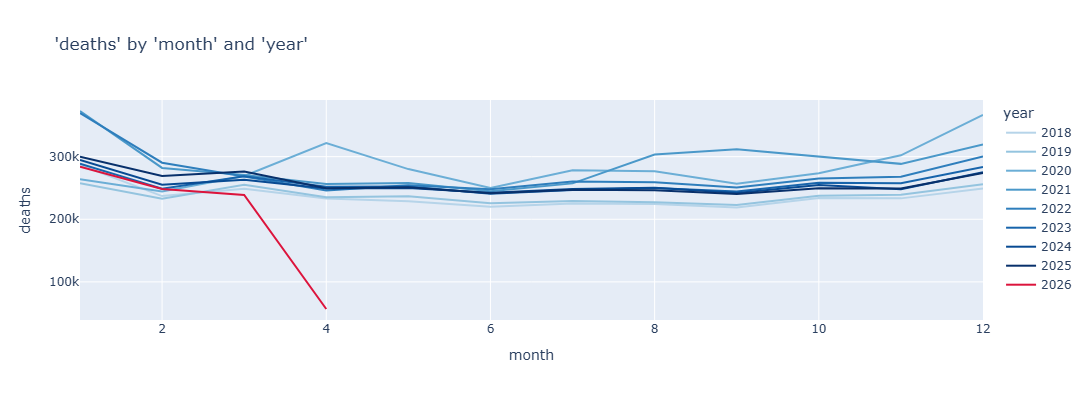

In [27]:
charters.chart(
    df=mcd18_monthly,
    x_axis="month",
    y_axis="deaths",
    color="year",
    type="line",
    color_discrete_map=color_discrete_map,
)

### Chart (cod)

In [185]:
# remap icd and filter
monthly_cod = cdc.map_reference(
    df=monthly_cod, col="simple_chapter", on_dict={"icd_chapter": "wonder_chapter"}
)

In [186]:
chapters = ["infectious","respiratory","special"]

monthly_cod_filtered = monthly_cod[monthly_cod["simple_chapter"].isin(chapters)].copy()

# zero out the pandemic (2020-2022)
mask_excluded = monthly_cod_filtered["year"].between(2020, 2022)
monthly_cod_filtered.loc[mask_excluded, "deaths"] = np.nan

# compute monthly_avg using 2019 and prior
max_date = monthly_cod_filtered["reported_date"].max()
cutoff = max_date - pd.DateOffset(months=2)
monthly_avg = (
    monthly_cod_filtered[monthly_cod_filtered["year"]<=2019]
    .groupby(["reported_date", "month"])["deaths"]
    .sum()
    .groupby(level="month")
    .mean()
)

# map the average
monthly_cod_filtered["avg"] = monthly_cod_filtered["month"].map(monthly_avg)
monthly_cod_filtered.loc[monthly_cod_filtered["reported_date"] > cutoff, "avg"] = np.nan
monthly_cod_filtered.loc[mask_excluded, "avg"] = np.nan

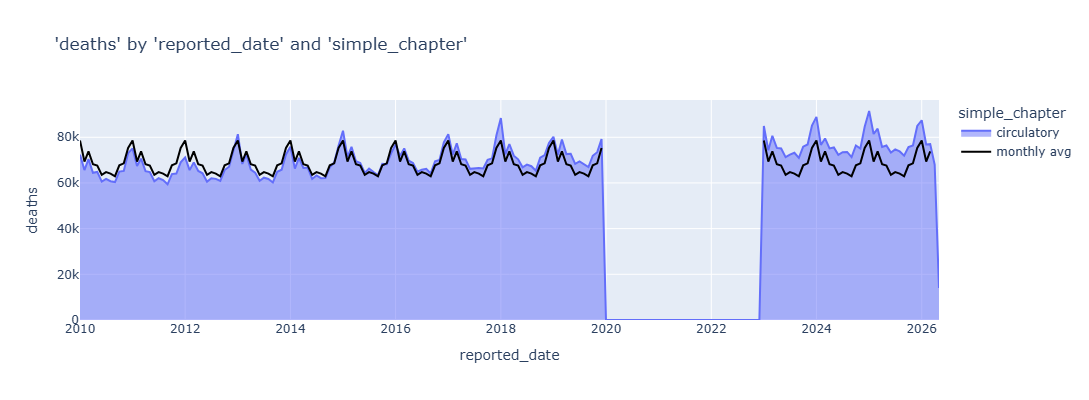

In [187]:
fig = charters.chart(
    df=monthly_cod_filtered,
    x_axis="reported_date",
    y_axis="deaths",
    color="simple_chapter",
    type="area",
)

# add average
fig.add_trace(
    go.Scatter(
        x=monthly_cod_filtered["reported_date"],
        y=monthly_cod_filtered["avg"],
        mode="lines",
        name="monthly avg",
        line=dict(color="black", width=2),
    )
)
fig

## Weekly

### SQL

In [20]:
mcd18_weekly = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_weekly")

In [29]:
IBNR_FACTORS = {
    0: 0.27,
    1: 0.64,
    2: 0.76,
    3: 0.85,
    4: 0.90,
    5: 0.94,
    6: 0.96,
    7: 0.97,
    8: 0.98,
    9: 0.99,
    10: 0.99,
    11: 0.99,
    12: 0.99,
    13: 0.99,
}

In [30]:
# remove na
mcd18_weekly.dropna(subset=["mmwr_week"], inplace=True)
mcd18_weekly = mcd18_weekly.sort_values("mmwr_week_date").reset_index(drop=True)
# add week_lag
mcd18_weekly["recent_week"] = range(len(mcd18_weekly) - 1, -1, -1)
# adjust for lag
years = sorted(mcd18_weekly["mmwr_year"].unique())
current_year = years[-1]
prior_years = years[:-1]
current_year_adj = mcd18_weekly[mcd18_weekly["mmwr_year"] == current_year].copy()
current_year_adj["deaths"] = current_year_adj["deaths"] / current_year_adj[
    "recent_week"
].map(IBNR_FACTORS).fillna(1.0)
current_year_adj = current_year_adj[current_year_adj["recent_week"] >= 3]
current_year_adj["mmwr_year"] = f"{current_year}_adj"
mcd18_weekly = pd.concat([mcd18_weekly, current_year_adj], ignore_index=True)

In [151]:
mcd18_weekly_pic = cdc.get_cdc_data_sql(
    db_filepath=db_filepath, table_name="mcd18_weekly_pic"
)

### Chart (all)

In [31]:
prior_colors = px.colors.sample_colorscale(
    "Blues",
    [0.3 + 0.7 * i / max(len(prior_years) - 1, 1) for i in range(len(prior_years))],
)
color_discrete_map = dict(zip(prior_years, prior_colors))
color_discrete_map[current_year] = "crimson"
color_discrete_map[f"{current_year}_adj"] = "crimson"

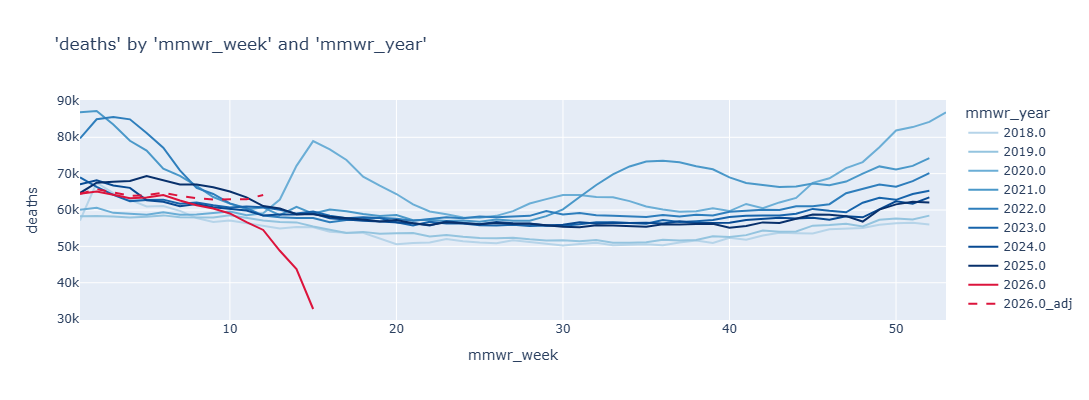

In [32]:
fig = charters.chart(
    df=mcd18_weekly,
    x_axis="mmwr_week",
    y_axis="deaths",
    color="mmwr_year",
    type="line",
    color_discrete_map=color_discrete_map,
)
for trace in fig.data:
    if trace.name == f"{current_year}_adj":
        trace.line.dash = "dash"
fig

### Chart (flu)

In [152]:
# filter 
mcd18_weekly_pic = mcd18_weekly_pic[
    mcd18_weekly_pic["icd_chapter"] == "Diseases of the respiratory system"
]
max_date = mcd18_weekly_pic["mmwr_week_date"].max()
cutoff = max_date - pd.Timedelta(weeks=7)
# compute average
weekly_avg = (
    mcd18_weekly_pic[mcd18_weekly_pic["mmwr_week_date"] <= cutoff]
    .groupby("mmwr_week")["deaths"]
    .mean()
)
mcd18_weekly_pic["avg"] = mcd18_weekly_pic["mmwr_week"].map(weekly_avg)
mcd18_weekly_pic.loc[mcd18_weekly_pic["mmwr_week_date"] > cutoff, "avg"] = (
    None
)

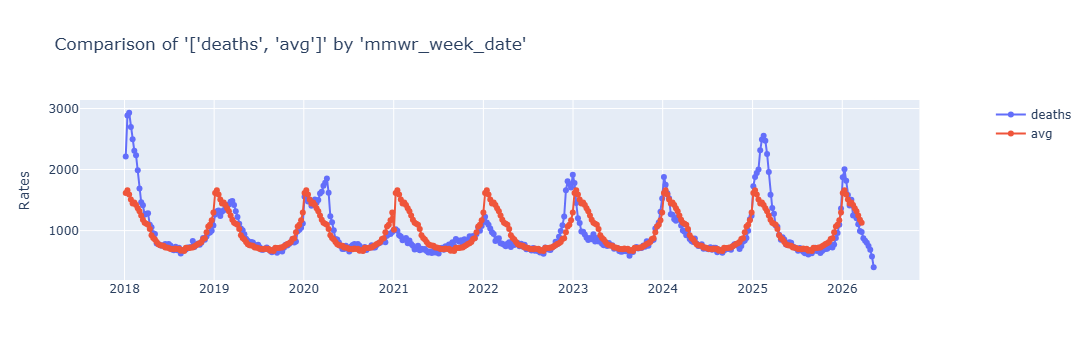

In [153]:
cdc_flu_chart = charters.compare_rates(
    df=mcd18_weekly_pic,
    x_axis="mmwr_week_date",
    rates=["deaths", "avg"],
)
cdc_flu_chart

## MI

### SQL

In [11]:
mcd79_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd79_mi")
mcd99_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_mi")
mcd18_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_mi")
mcd18_mi = mcd18_mi[mcd18_mi["year"] >= 2021]
mi = pd.concat([mcd79_mi, mcd99_mi, mcd18_mi], axis=0, ignore_index=True)

In [54]:
mi = cdc.map_reference(
    df=mi,
    col="value",
    on_dict={"age_groups": "key"},
    sheet_name="mapping",
    category="bin_age",
)
mi = mi.drop("age_groups", axis=1)
mi = mi.rename(columns={"value": "age_groups"})

### Calculate

In [55]:
# filters
mi = mi[(mi["year"] < 2020) | ((mi["year"] >= 2024) & (mi["year"] < 2026))]

In [56]:
mi_df = cdc.calc_mi(df=mi, rolling=10)

 2026-05-04 14:35:13 | morai.integrations.cdc | INFO     | calculating mortality improvement by using a `2000 age adjusted` crude mortality rate 


### Chart

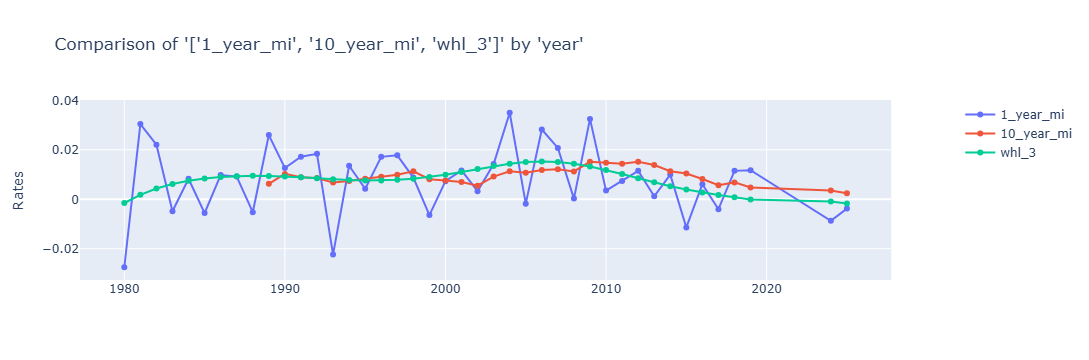

In [57]:
charters.compare_rates(
    df=mi_df,
    x_axis="year",
    rates=["1_year_mi", "10_year_mi", "whl_3"],
)

## Excess

### SQL

In [9]:
TRAIN_START_YEAR = 2015
TRAIN_END_YEAR = 2019
NEW_DATASET_START_YEAR= 2021

In [10]:
mcd99_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_mi")
mcd18_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_mi")
mcd18_mi = mcd18_mi[mcd18_mi["year"] >= NEW_DATASET_START_YEAR]
excess = pd.concat([mcd99_mi, mcd18_mi], axis=0, ignore_index=True)

In [11]:
excess = cdc.map_reference(
    df=excess,
    col="value",
    on_dict={"age_groups": "key"},
    sheet_name="mapping",
    category="bin_age_int",
)
excess = excess.rename(columns={"value": "mapped_age"})

In [12]:
# normalize partial deaths in recent year
excess["deaths"] = excess["deaths"].astype(float)
data_through = pd.Timestamp(mcd18_mi["data_through"].max())
start_of_year = pd.Timestamp(f"{data_through.year}-01-01")
days_elapsed = (data_through - start_of_year).days + 1
factor = 365 / days_elapsed
mask = excess["year"] == data_through.year
excess.loc[mask, "deaths"] = excess.loc[mask, "deaths"] * factor

In [13]:
excess_grouped = (
    excess.groupby(["year", "mapped_age"], observed=True)
    .sum(numeric_only=True)
    .reset_index()
)
excess_grouped = excess_grouped[(excess_grouped["year"] >= TRAIN_START_YEAR)]

In [15]:
# adjust population
# train the data based on year and the category using linear regression
max_year = excess_grouped["year"].max()
base_year = max_year - 2
train_df = excess_grouped[
    (excess_grouped["year"] >= TRAIN_START_YEAR) & (excess_grouped["year"] <= TRAIN_END_YEAR)
]
train_df = train_df.groupby(["year", "mapped_age"])["population"].sum().reset_index()

# create the age models
models = {}
for age in train_df["mapped_age"].unique():
    age_subset = train_df[train_df["mapped_age"] == age]
    X = (age_subset["year"] - TRAIN_START_YEAR).values.reshape(-1, 1)
    y = age_subset["population"].values
    model = LinearRegression().fit(X, y)
    models[age] = {
        "model": model,
        "coef": model.coef_[0],
        "intercept": model.intercept_,
    }
bases = (
    excess_grouped[excess_grouped["year"] == base_year]
    .set_index("mapped_age")["population"]
    .to_dict()
)
coefs = {age: m["coef"] / m["intercept"] for age, m in models.items()}

# prediction
for year in [base_year + 1, base_year + 2]:
    mask = excess_grouped["year"] == year
    for age in excess_grouped.loc[mask, "mapped_age"].unique():
        coef = coefs.get(age, 0)
        base = bases.get(age, 0)
        idx = (excess_grouped["year"] == year) & (excess_grouped["mapped_age"] == age)
        excess_grouped.loc[idx, "population"] = (1 + coef) ** (year - base_year) * base

In [16]:
excess_grouped["qx_raw"] = excess_grouped["deaths"] / excess_grouped["population"]
forecast_years = max_year - TRAIN_END_YEAR

### Calculate

In [17]:
train_df = excess_grouped[
    (excess_grouped["year"] >= TRAIN_START_YEAR) & (excess_grouped["year"] <= TRAIN_END_YEAR)
].copy()
model = core.LeeCarter(
    age_col="mapped_age",
    year_col="year",
    actual_col="deaths",
    expose_col="population",
    interval=1,
)
fit_df = model.structure_df(train_df)
fit_df = model.fit(fit_df)

 2026-08-16 13:01:55 | morai.models.core | INFO     | initialized LeeCarter 
 2026-08-16 13:01:55 | morai.models.core | INFO     | grouping data by age and year 
 2026-08-16 13:01:55 | morai.models.core | INFO     | calculating qx_raw rates using deaths and population 
 2026-08-16 13:01:55 | morai.models.core | INFO     | floored 0 rates to 0.000001 and capped 0 rates to 0.999999. 
 2026-08-16 13:01:55 | morai.models.core | INFO     | crude_df shape: (55, 5) 
 2026-08-16 13:01:55 | morai.models.core | INFO     | creating Lee Carter model with qx_raw rates... 
 2026-08-16 13:01:55 | morai.models.core | INFO     | age range: 0, 85 
 2026-08-16 13:01:55 | morai.models.core | INFO     | year range: 2015, 2019 
 2026-08-16 13:01:55 | morai.models.core | INFO     | creating `11` intervals 
 2026-08-16 13:01:56 | morai.models.core | INFO     | adding qx_lc to lc_df 


In [18]:
forecast_df = model.forecast(years=forecast_years)
forecast_df = pd.concat(
    [fit_df[["year", "mapped_age", "qx_lc"]], forecast_df], axis=0
).reset_index()

 2026-08-16 13:01:56 | morai.models.core | INFO     | forecasting qx_lc using deterministic random walk... 


In [19]:
excess_grouped = pd.merge(
    excess_grouped,
    forecast_df[["mapped_age", "year", "qx_lc"]],
    on=["mapped_age", "year"],
    how="left",
)
excess_grouped["deaths_lc"] = excess_grouped["population"] * excess_grouped["qx_lc"]

In [20]:
result = (
    excess_grouped.groupby(["year"], observed=True).sum(numeric_only=True).reset_index()
)
result["excess_lc"] = result["deaths"] / result["deaths_lc"]
result["crude_rt"] = result["deaths"] / result["population"] * 100000
result["crude_rt_lc"] = result["deaths_lc"] / result["population"] * 100000

### Chart

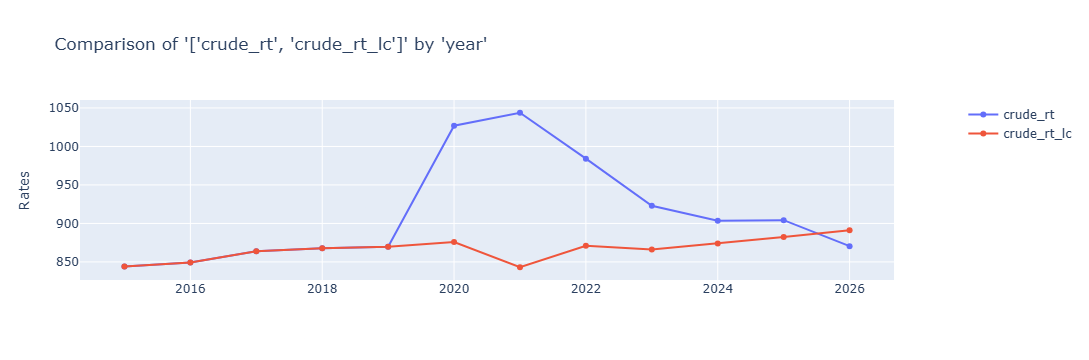

In [66]:
charters.compare_rates(
    result,
    x_axis="year",
    rates=["crude_rt", "crude_rt_lc"],
)

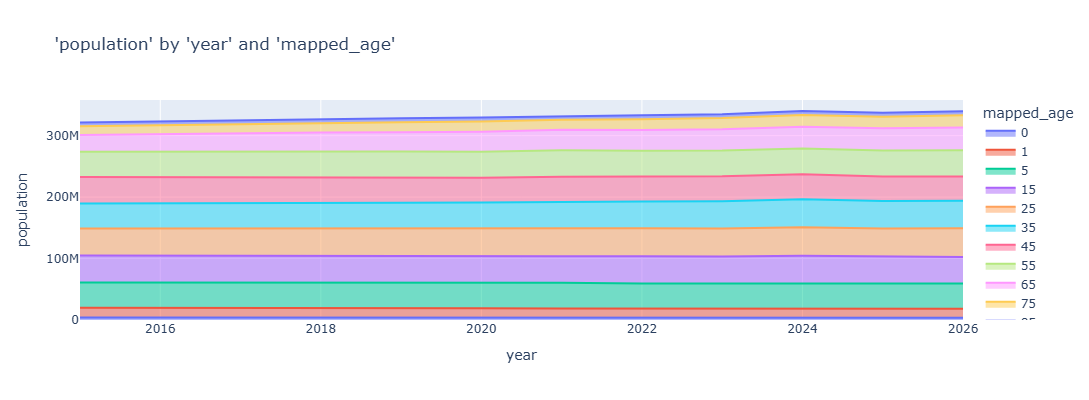

In [18]:
charters.chart(
    excess_grouped,
    x_axis="year",
    y_axis="population",
    color="mapped_age",
    type="area",
)

#### CBD

In [51]:
train_df = excess_grouped[
    (excess_grouped["year"] >= 2015) & (excess_grouped["year"] <= 2019)
].copy()
model = core.CBD(
    age_col="mapped_age",
    year_col="year",
    actual_col="deaths",
    expose_col="population",
    interval=3,
)
fit_df = model.structure_df(train_df)
fit_df = model.fit(fit_df)

 2026-04-30 22:42:14 | morai.models.core | INFO     | initialized CBD 
 2026-04-30 22:42:14 | morai.models.core | INFO     | grouping data by age and year 
 2026-04-30 22:42:14 | morai.models.core | INFO     | calculating qx_raw rates using deaths and population 
 2026-04-30 22:42:14 | morai.models.core | INFO     | floored 0 rates to 0.000001 and capped 0 rates to 0.999999. 
 2026-04-30 22:42:14 | morai.models.core | INFO     | cbd_df shape: (55, 5) 
 2026-04-30 22:42:14 | morai.models.core | INFO     | creating CBD model with qx_raw rates... 
 2026-04-30 22:42:14 | morai.models.core | INFO     | age range: 0, 85 
 2026-04-30 22:42:14 | morai.models.core | INFO     | year range: 2015, 2019 
 2026-04-30 22:42:14 | morai.models.core | INFO     | creating `3` intervals 
 2026-04-30 22:42:14 | morai.models.core | INFO     | adding qx_cbd to cbd_df 


In [52]:
forecast_df = model.forecast(years=7)
forecast_df = pd.concat(
    [fit_df[["year", "mapped_age", "qx_cbd"]], forecast_df], axis=0
).reset_index()

 2026-04-30 22:42:15 | morai.models.core | INFO     | forecasting qx_cbd using deterministic random walk... 


In [53]:
excess_grouped = pd.merge(
    excess_grouped,
    forecast_df[["mapped_age", "year", "qx_cbd"]],
    on=["mapped_age", "year"],
    how="left",
)
excess_grouped["deaths_cbd"] = excess_grouped["population"] * excess_grouped["qx_cbd"]

In [57]:
result = (
    excess_grouped.groupby(["year"], observed=True).sum(numeric_only=True).reset_index()
)
result["excess_lc"] = result["deaths"] / result["deaths_lc"]
result["crude_rt"] = result["deaths"] / result["population"] * 100000
result["crude_rt_lc"] = result["deaths_lc"] / result["population"] * 100000
result["crude_rt_cbd"] = result["deaths_cbd"] / result["population"] * 100000

In [ ]:
charters.compare_rates(
    result,
    x_axis="year",
    rates=["crude_rt", "crude_rt_lc", "crude_rt_cbd"],
)

## Refresh Tables

In [ ]:
break

COD tables

In [19]:
mcd99_9910_cod = cdc.get_cdc_data_xml(xml_filename="mcd99_9910_cod.xml")
sql.export_to_sql(
    df=mcd99_9910_cod,
    db_filepath=db_filepath,
    table_name="mcd99_cod",
    if_exists="replace",
)
mcd99_1120_cod = cdc.get_cdc_data_xml(xml_filename="mcd99_1120_cod.xml")
sql.export_to_sql(
    df=mcd99_1120_cod,
    db_filepath=db_filepath,
    table_name="mcd99_cod",
    if_exists="append",
)

 2026-04-28 00:23:01 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd99_cod` 
 2026-04-28 00:23:31 | morai.utils.sql | INFO     | append data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd99_cod` 


In [166]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_cod.xml")
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_cod",
    if_exists="replace",
)

 2026-04-30 09:46:20 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd18_cod` 


Monthly Tables

In [188]:
df = cdc.get_cdc_data_xml(xml_filename="mcd99_monthly_cod.xml", parse_date_col="Month")
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd99_monthly_cod",
    if_exists="replace",
)

 2026-05-23 00:27:59 | morai.utils.sql | INFO     | replace data to SQLite database: `C:\Users\johnk\Desktop\github\configs\morai\files\integrations\cdc\cdc.sql` and table: `mcd99_monthly_cod` 


In [9]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_monthly.xml", parse_date_col="Month")
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_monthly",
    if_exists="replace",
)

 2026-05-12 23:26:21 | morai.utils.sql | INFO     | replace data to SQLite database: `C:\Users\johnk\Desktop\github\configs\morai\files\integrations\cdc\cdc.sql` and table: `mcd18_monthly` 


In [190]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_monthly_cod.xml", parse_date_col="Month")
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_monthly_cod",
    if_exists="replace",
)

 2026-05-23 00:28:38 | morai.utils.sql | INFO     | replace data to SQLite database: `C:\Users\johnk\Desktop\github\configs\morai\files\integrations\cdc\cdc.sql` and table: `mcd18_monthly_cod` 


Weekly Tables

In [9]:
df = cdc.get_cdc_data_xml(
    xml_filename="mcd18_weekly.xml", parse_date_col="mmwr_week_date"
)
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_weekly",
    if_exists="replace",
)

 2026-04-28 00:19:17 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd18_weekly` 


In [137]:
df = cdc.get_cdc_data_xml(
    xml_filename="mcd18_weekly_pic.xml", parse_date_col="mmwr_week_date"
)
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_weekly_pic",
    if_exists="replace",
)

 2026-05-21 19:36:50 | morai.utils.sql | INFO     | replace data to SQLite database: `C:\Users\johnk\Desktop\github\configs\morai\files\integrations\cdc\cdc.sql` and table: `mcd18_weekly_pic` 


MI Tables

In [40]:
df = cdc.get_cdc_data_xml(xml_filename="mcd79_mi.xml")
df["quintile"] = "total"
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd79_mi",
    if_exists="replace",
)

 2026-04-28 23:38:43 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd79_mi` 


In [42]:
df = cdc.get_cdc_data_xml(xml_filename="mcd99_mi.xml")
df["quintile"] = "total"
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd99_mi",
    if_exists="replace",
)

 2026-04-28 23:39:08 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd99_mi` 


In [23]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_mi.xml")
df["quintile"] = "total"
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_mi",
    if_exists="replace",
)

 2026-08-16 13:20:58 | morai.utils.sql | INFO     | replace data to SQLite database: `C:\Users\johnk\Desktop\github\configs\morai\files\integrations\cdc\cdc.sql` and table: `mcd18_mi` 


## Compare CDC to SQL database

### CDC Query

In [118]:
df = cdc.get_cdc_data_xml(xml_filename="mcd79_check.xml")

In [119]:
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd79_check",
    if_exists="replace",
)

 2026-04-30 22:29:27 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd79_check` 


In [121]:
df = cdc.get_cdc_data_xml(xml_filename="mcd99_check.xml")

In [122]:
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd99_check",
    if_exists="replace",
)

 2026-04-30 22:29:49 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd99_check` 


In [123]:
df = cdc.get_cdc_data_xml(xml_filename="mcd18_check.xml")

In [124]:
sql.export_to_sql(
    df=df,
    db_filepath=db_filepath,
    table_name="mcd18_check",
    if_exists="replace",
)

 2026-04-30 22:30:07 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/cdc/cdc.sql` and table: `mcd18_check` 


### SQL

In [125]:
mcd79_check = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd79_check")

In [126]:
mcd99_check = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_check")

In [127]:
mcd18_check = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_check")

### Compare

In [128]:
cdc.compare_dfs(mcd79_check, mcd79_mi)

,year,deaths_left,deaths_right,deaths_diff
0,1979,1913841,1913841,0
1,1980,1989841,1989841,0
2,1981,1977981,1977981,0
3,1982,1974797,1974797,0
4,1983,2019201,2019201,0
5,1984,2039369,2039369,0
6,1985,2086440,2086440,0
7,1986,2105361,2105361,0
8,1987,2123323,2123323,0
9,1988,2167999,2167999,0


In [129]:
cdc.compare_dfs(mcd99_check, mcd99_cod)

,year,deaths_left,deaths_right,deaths_diff
0,1999,2391399,2389832,1567
1,2000,2403351,2401732,1619
2,2001,2416425,2414828,1597
3,2002,2443387,2441689,1698
4,2003,2448288,2446680,1608
5,2004,2397615,2395904,1711
6,2005,2448017,2446342,1675
7,2006,2426264,2424705,1559
8,2007,2423712,2422082,1630
9,2008,2471984,2470367,1617


In [130]:
cdc.compare_dfs(mcd18_check, mcd18_monthly)

,year,deaths_left,deaths_right,deaths_diff
0,2018,2839205,2839205,0
1,2019,2854838,2854838,0
2,2020,3383729,3383729,0
3,2021,3464231,3464231,0
4,2022,3279857,3279857,0
5,2023,3090964,3090964,0
6,2024,3072666,3072666,0
7,2025,3094078,3093652,426
8,2026,895831,828163,67668


## Other Functions

In [ ]:
sql.table_remove(db_filepath=db_filepath, table_name="mcd79_mi")

In [131]:
sql.table_dtypes(db_filepath=db_filepath, table_name="mcd79_mi")

{'age_groups': 'TEXT',
 'gender': 'TEXT',
 'year': 'INTEGER',
 'deaths': 'INTEGER',
 'population': 'REAL',
 'crude_rate': 'TEXT',
 'data_through': 'TEXT',
 'quintile': 'TEXT',
 'added_at': 'TEXT'}

## Reload

In [ ]:
import importlib

importlib.reload(cdc)

In [ ]:
importlib.reload(sql)